# Downgrade quality: real d10 template

This notebook compares `ud_grade`, `harmonic_ud_grade`, and `smoothing + ud_grade` on the real d10 353 GHz intensity template.

Because there is no independent target-NSIDE truth map for d10, the notebook focuses on relative diagnostics tied back to the original map. The default `harmonic_ud_grade` setting now uses `lmax = 3*nside_out - 1`, so the notebook shows a single harmonic downgrade curve.

In [1]:
from pathlib import Path
import urllib.request

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt


In [2]:
def _round_sig(x, sig=2):
    if x == 0 or not np.isfinite(x):
        return float(x)
    return float(np.round(x, sig - int(np.floor(np.log10(abs(x)))) - 1))

def rounded_limits(*maps, q=(0.5, 99.5)):
    vals = np.concatenate([m[np.isfinite(m)] for m in maps])
    lo, hi = np.percentile(vals, q)
    vmin = _round_sig(float(lo), sig=2)
    vmax = _round_sig(float(hi), sig=2)
    if vmin == vmax:
        vmax = vmin + 1.0
    return vmin, vmax

def proj_panels(maps, titles, cmap='RdBu_r', q=(0.5, 99.5), ncol=3, xsize=2200, symmetric=False):
    vmin, vmax = rounded_limits(*maps, q=q)
    if symmetric:
        lim = max(abs(vmin), abs(vmax))
        vmin, vmax = -lim, lim
    print(f'vmin={vmin}, vmax={vmax}')
    n = len(maps)
    ncol = min(ncol, n)
    nrow = int(np.ceil(n / ncol))
    plt.figure(figsize=(6.8*ncol, 4.8*nrow))
    for i, (m, t) in enumerate(zip(maps, titles), start=1):
        hp.projview(
            m,
            sub=(nrow, ncol, i),
            title=t,
            min=vmin,
            max=vmax,
            cmap=cmap,
            graticule=True,
            xsize=xsize,
            cb_orientation='horizontal',
        )
    plt.tight_layout()

def compare_to_ref(m, m_ref, cl, cl_ref, ell_min=2):
    good = np.isfinite(m) & np.isfinite(m_ref)
    m0 = m[good]
    r0 = m_ref[good]
    rmse_rel = np.sqrt(np.mean((m0-r0)**2)) / np.std(r0)
    mae_rel = np.mean(np.abs(m0-r0)) / np.std(r0)
    corr = np.corrcoef(m0, r0)[0, 1]
    spec_rel_l2 = np.linalg.norm(cl[ell_min:] - cl_ref[ell_min:]) / np.linalg.norm(cl_ref[ell_min:])
    return {
        'rmse_rel_std': float(rmse_rel),
        'mae_rel_std': float(mae_rel),
        'map_corr': float(corr),
        'spec_rel_l2': float(spec_rel_l2),
    }

def moll_diff_panels(diff_maps, titles, unit='', q=(0.2, 99.8)):
    vmin, vmax = rounded_limits(*diff_maps, q=q)
    lim = max(abs(vmin), abs(vmax))
    vmin, vmax = -lim, lim
    print(f'moll diff scale: vmin={vmin}, vmax={vmax}')
    n = len(diff_maps)
    fig = plt.figure(figsize=(6.8*n, 5.0))
    for i, (m, t) in enumerate(zip(diff_maps, titles), start=1):
        hp.mollview(
            m,
            fig=fig.number,
            sub=(1, n, i),
            title=t,
            min=vmin,
            max=vmax,
            cmap='RdBu_r',
            unit=unit,
            cbar=True,
        )
    plt.tight_layout()


## 2) Real d10 353 GHz intensity template (direct download, no PySM)

In [3]:
base_url = 'https://portal.nersc.gov/project/cmb/pysm-data'
relpath = 'dust_gnilc/gnilc_dust_template_nside2048_2023.02.10.fits'
url = f'{base_url}/{relpath}'

cache_dir = Path('/tmp/pysm_data')
cache_dir.mkdir(parents=True, exist_ok=True)
local_path = cache_dir / Path(relpath).name
if not local_path.exists():
    print('Downloading', url)
    urllib.request.urlretrieve(url, local_path)
print('Local file:', local_path)

Local file: /tmp/pysm_data/gnilc_dust_template_nside2048_2023.02.10.fits


In [4]:
m_d10 = hp.read_map(local_path, field=0, dtype=np.float64)
nside_d10 = hp.get_nside(m_d10)
print('d10 nside:', nside_d10, 'npix:', m_d10.size)

d10 nside: 2048 npix: 50331648


In [5]:
nside_out_real = 128
lmax_real = 3*nside_out_real - 1

d10_ud = hp.ud_grade(m_d10, nside_out=nside_out_real)
d10_harm = hp.harmonic_ud_grade(m_d10, nside_out=nside_out_real)
d10_smooth_ud = hp.ud_grade(hp.smoothing(m_d10, fwhm=np.radians(30/60)), nside_out=nside_out_real)

vmin=35.0, vmax=2900.0


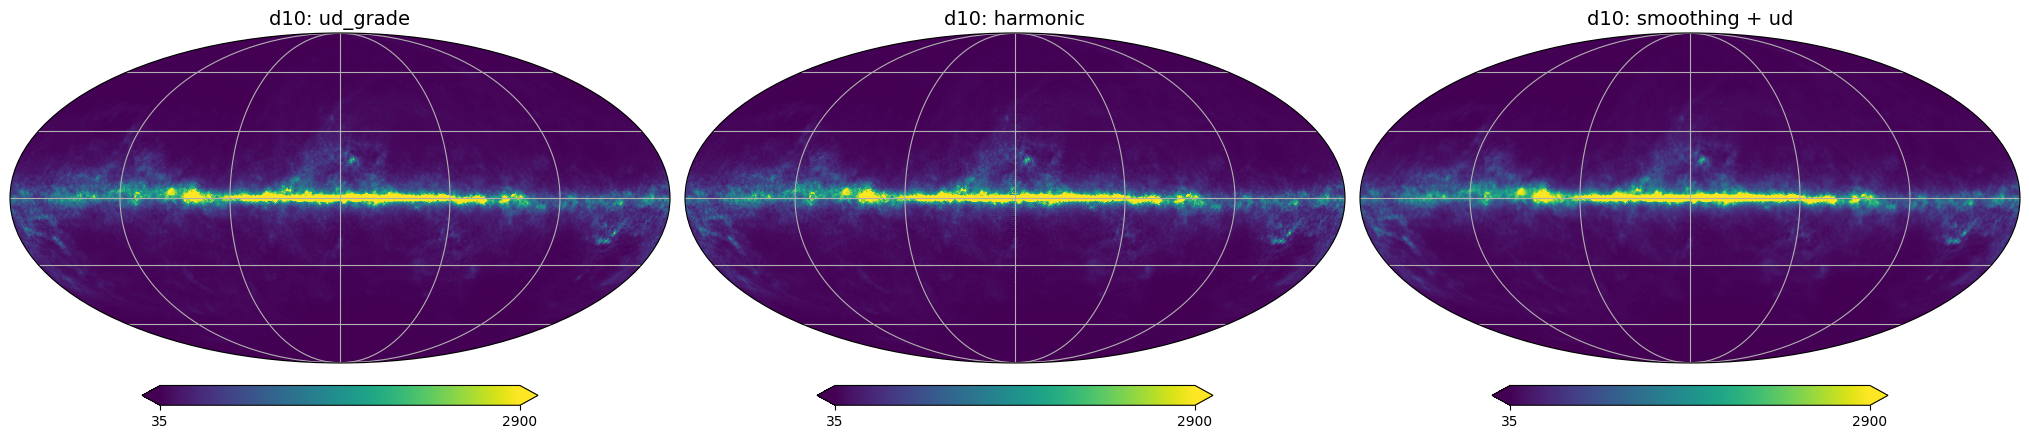

In [6]:
proj_panels(
    [d10_ud, d10_harm, d10_smooth_ud],
    ['d10: ud_grade', 'd10: harmonic', 'd10: smoothing + ud'],
    cmap='viridis',
    q=(1, 99),
)

### d10 residual maps (visual check)
For d10, there is no independent target-NSIDE ground-truth map analogous to `m_ref` in the synthetic case.
Therefore this section uses relative diagnostics (method-to-method residual maps and spectra) rather than the scalar truth-referenced metrics used in Section 1.


vmin=-260.0, vmax=260.0


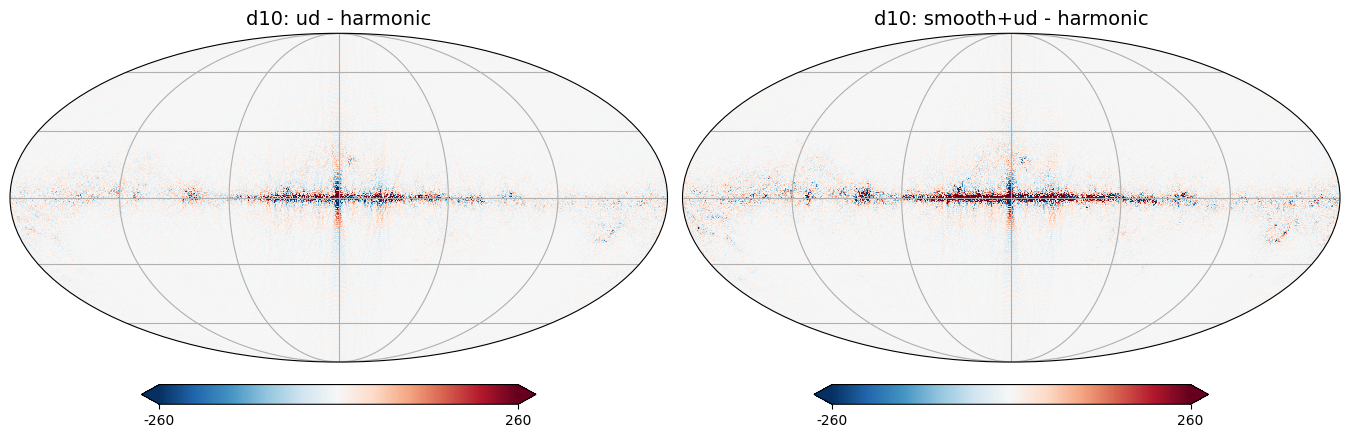

In [7]:
d10_ref = d10_harm
proj_panels(
    [d10_ud - d10_ref, d10_smooth_ud - d10_ref],
    ['d10: ud - harmonic', 'd10: smooth+ud - harmonic'],
    cmap='RdBu_r',
    q=(0.2, 99.8),
    symmetric=True,
)

### d10 Mollweide differences vs harmonic comparison map
Mollweide residuals use the same symmetric color range across methods. These are method-to-method comparison plots only; they are not treated as a truth-reference diagnostic.

moll diff scale: vmin=-260.0, vmax=260.0


/tmp/ipykernel_12618/160289878.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


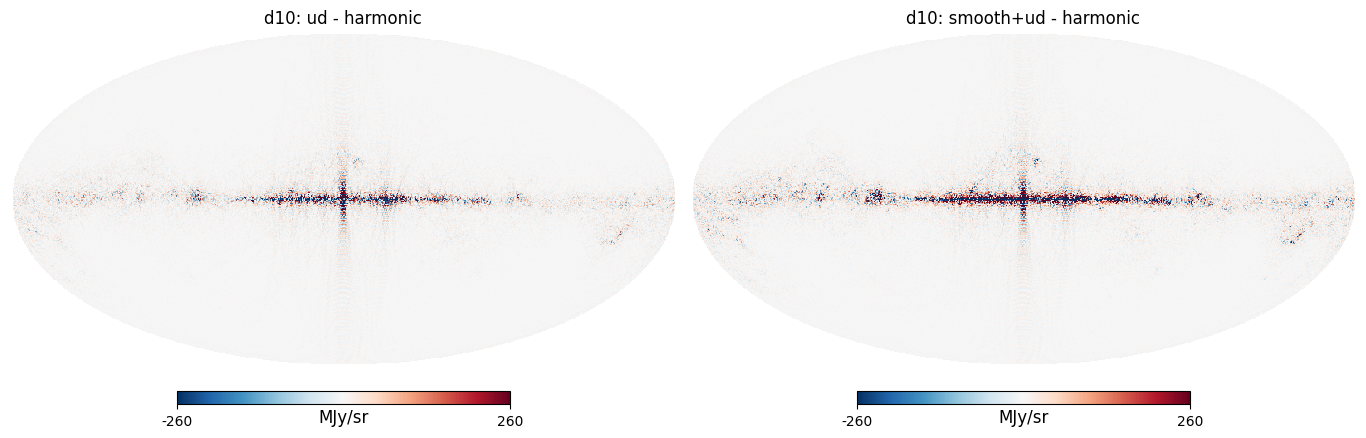

In [8]:
moll_diff_panels(
    [d10_ud - d10_ref, d10_smooth_ud - d10_ref],
    ['d10: ud - harmonic', 'd10: smooth+ud - harmonic'],
    unit='MJy/sr',
    q=(0.2, 99.8),
)

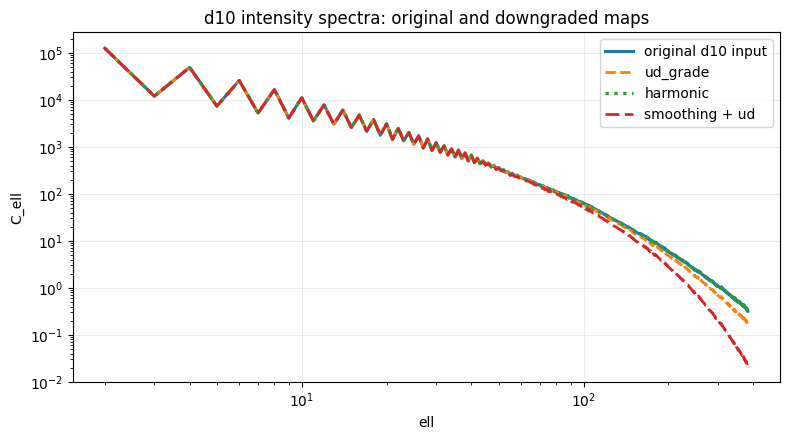

In [9]:
cl_d10_orig = hp.anafast(m_d10, lmax=lmax_real)
cl_d10_ud = hp.anafast(d10_ud, lmax=lmax_real)
cl_d10_harm = hp.anafast(d10_harm, lmax=lmax_real)
cl_d10_smooth_ud = hp.anafast(d10_smooth_ud, lmax=lmax_real)
ell_real = np.arange(lmax_real + 1)

line_styles = {
    'original': '-',
    'ud_grade': '--',
    'harmonic': ':',
    'smoothing_ud': (0, (5, 2)),
}

plt.figure(figsize=(8,4.5))
plt.loglog(ell_real[2:], cl_d10_orig[2:], label='original d10 input', linestyle=line_styles['original'], linewidth=2.2)
plt.loglog(ell_real[2:], cl_d10_ud[2:], label='ud_grade', linestyle=line_styles['ud_grade'], linewidth=2.0)
plt.loglog(ell_real[2:], cl_d10_harm[2:], label='harmonic', linestyle=line_styles['harmonic'], linewidth=2.4)
plt.loglog(ell_real[2:], cl_d10_smooth_ud[2:], label='smoothing + ud', linestyle=line_styles['smoothing_ud'], linewidth=2.0)
plt.xlabel('ell')
plt.ylabel('C_ell')
plt.title('d10 intensity spectra: original and downgraded maps')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

### How to read the unmasked d10 spectrum
- `original d10 input` is the high-resolution template spectrum, truncated at the target comparison bandlimit $l_{\max} = 3\,N_{\mathrm{side,out}} - 1$.
- This panel should be read as a fidelity-to-original diagnostic, not as a proof of aliasing by itself.
- `harmonic` preserves more of the original target-bandlimited structure than `smoothing + ud` while remaining a cleaner spectral approximation than `ud_grade` in this notebook.
- `ud_grade` should be judged against that same original-spectrum baseline: if it departs more strongly from the original over the retained band, it is doing a worse job of preserving the original map content after downgrade.
- `smoothing + ud` damps the spectrum more strongly because the explicit beam smoothing removes additional small-scale structure before the downgrade.

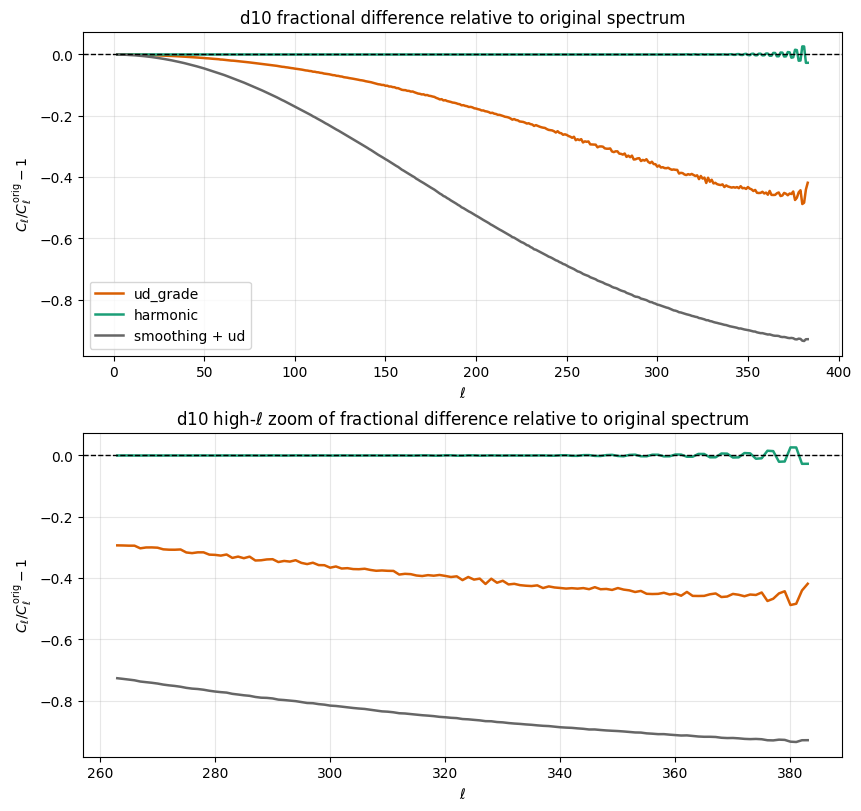

In [10]:
ell_zoom_min = max(2, lmax_real - 120)
good_all = ell_real >= 2
good_zoom = (ell_real >= ell_zoom_min) & (ell_real <= lmax_real)

baseline_cl = cl_d10_orig
comparisons = [
    ('ud_grade', cl_d10_ud, '#d95f02'),
    ('harmonic', cl_d10_harm, '#1b9e77'),
    ('smoothing + ud', cl_d10_smooth_ud, '#666666'),
]

fig, axes = plt.subplots(2, 1, figsize=(8.5, 8.0), constrained_layout=True)
for label, cl_arr, color in comparisons:
    frac_all = cl_arr[good_all] / baseline_cl[good_all] - 1.0
    frac_zoom = cl_arr[good_zoom] / baseline_cl[good_zoom] - 1.0
    axes[0].plot(ell_real[good_all], frac_all, linewidth=1.8, label=label, color=color)
    axes[1].plot(ell_real[good_zoom], frac_zoom, linewidth=1.8, label=label, color=color)

for ax in axes:
    ax.axhline(0.0, color='black', linestyle='--', linewidth=1)
    ax.set_ylabel(r'$C_\ell / C_\ell^{\mathrm{orig}} - 1$')
    ax.grid(alpha=0.3)

axes[0].set_title('d10 fractional difference relative to original spectrum')
axes[0].set_xlabel(r'$\ell$')
axes[0].legend()

axes[1].set_title('d10 high-$\ell$ zoom of fractional difference relative to original spectrum')
axes[1].set_xlabel(r'$\ell$')
plt.show()

The two-panel fractional-difference figure above uses the original d10 spectrum as the baseline.
The top panel shows the full multipole range, while the bottom panel zooms to the high-$\ell$ end where the downgrade differences are easiest to see.

Values below zero indicate loss of power relative to the original high-resolution template at the same multipole, while values above zero indicate excess power.
This figure is meant to compare fidelity to the original spectrum after downgrade. It should not be interpreted on its own as a direct aliasing diagnostic, because the original high-resolution spectrum is not itself the downgraded target.

### d10 spectra with Planck Galactic mask (large cut)
We apply a Planck Galactic mask (`GAL060`, from `HFI_Mask_GalPlane-apo0_2048_R2.00`) to emphasize high-latitude behavior and reduce Galactic-plane dominance in the spectra.


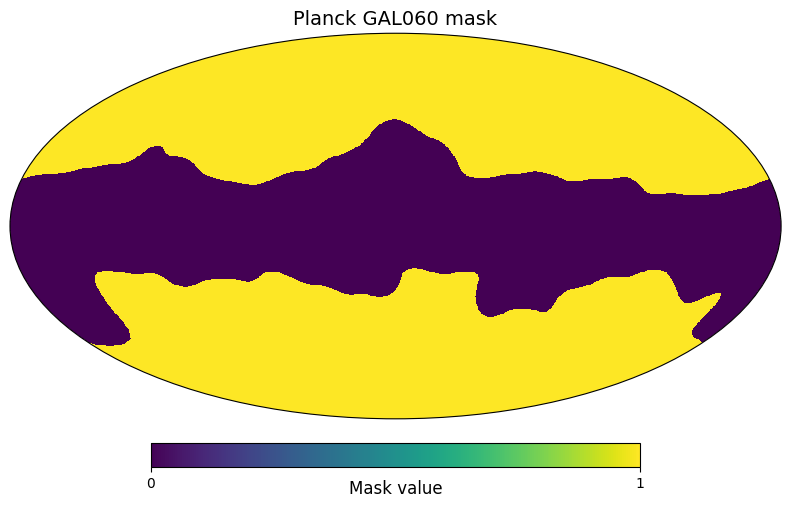

In [11]:
from astropy.io import fits
import urllib.request
from pathlib import Path
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

# Load the mask file (download if missing)
mask_filename = "HFI_Mask_GalPlane-apo0_2048_R2.00.fits"
mask_url = f"https://irsa.ipac.caltech.edu/data/Planck/release_2/ancillary-data/masks/{mask_filename}"
mask_cache_dir = Path("/tmp/planck_masks")
mask_cache_dir.mkdir(parents=True, exist_ok=True)
mask_path = mask_cache_dir / mask_filename
if not mask_path.exists():
    urllib.request.urlretrieve(mask_url, mask_path)

# Large Galactic cut: GAL060 keeps ~60% of sky (apodized).
mask_field = "GAL060"
with fits.open(mask_path) as hdul:
    col_names = list(hdul[1].columns.names)
mask_field_idx = col_names.index(mask_field)
mask_hi = hp.read_map(mask_path, field=mask_field_idx, dtype=np.float64)

# Plot the mask
hp.projview(mask_hi, title=f"Planck {mask_field} mask", unit="Mask value", min=0, max=1)
hp.graticule()

NaMaster mask field: GAL060 (column 2), f_sky_eff(nside=128)=0.599


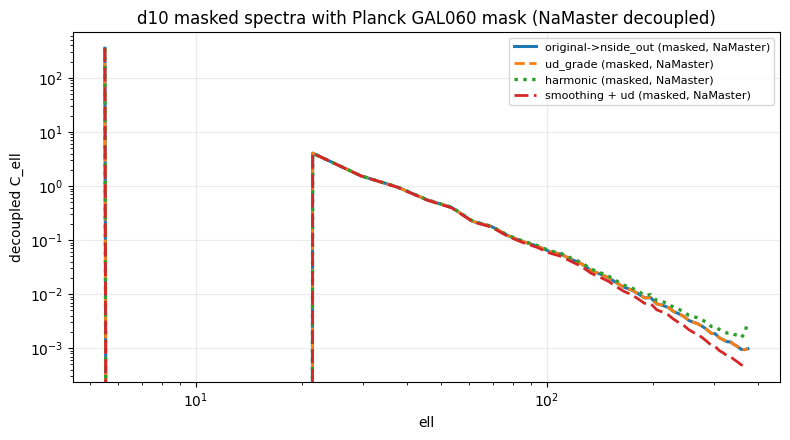

In [12]:
import pymaster as nmt

def mask_at_nside(mask, nside_out):
    nside_in = hp.get_nside(mask)
    if nside_in == nside_out:
        out = mask
    else:
        out = hp.ud_grade(mask, nside_out=nside_out)
    return np.clip(out, 0.0, 1.0)

def nmt_decoupled_cl(map_in, mask_base, lmax, nlb=8):
    nside = hp.get_nside(map_in)
    mask = mask_at_nside(mask_base, nside)
    fsky_eff = float(np.mean(mask**2))
    field = nmt.NmtField(mask, [map_in])
    b = nmt.NmtBin.from_nside_linear(nside, nlb=nlb, is_Dell=False)
    wsp = nmt.NmtWorkspace()
    wsp.compute_coupling_matrix(field, field, b)
    cl_coupled = nmt.compute_coupled_cell(field, field)
    cl_dec = wsp.decouple_cell(cl_coupled)[0]
    ells_eff = b.get_effective_ells()
    good = ells_eff <= lmax
    return ells_eff[good], cl_dec[good], fsky_eff

# For a fair low-resolution comparison, include an original-map baseline downgraded to target NSIDE.
d10_orig_to_out = hp.ud_grade(m_d10, nside_out=nside_out_real)

ell_nmt, cl_d10_orig_nmt, fsky_out = nmt_decoupled_cl(d10_orig_to_out, mask_hi, lmax_real)
_, cl_d10_ud_nmt, _ = nmt_decoupled_cl(d10_ud, mask_hi, lmax_real)
_, cl_d10_harm_nmt, _ = nmt_decoupled_cl(d10_harm, mask_hi, lmax_real)
_, cl_d10_smooth_ud_nmt, _ = nmt_decoupled_cl(d10_smooth_ud, mask_hi, lmax_real)

print(f"NaMaster mask field: {mask_field} (column {mask_field_idx}), f_sky_eff(nside={nside_out_real})={fsky_out:.3f}")

line_styles = {
    "original": "-",
    "ud_grade": "--",
    "harmonic": ":",
    "smoothing_ud": (0, (5, 2)),
}

plt.figure(figsize=(8,4.5))
plt.loglog(ell_nmt[ell_nmt>=2], cl_d10_orig_nmt[ell_nmt>=2], label="original->nside_out (masked, NaMaster)", linestyle=line_styles["original"], linewidth=2.2)
plt.loglog(ell_nmt[ell_nmt>=2], cl_d10_ud_nmt[ell_nmt>=2], label="ud_grade (masked, NaMaster)", linestyle=line_styles["ud_grade"], linewidth=2.0)
plt.loglog(ell_nmt[ell_nmt>=2], cl_d10_harm_nmt[ell_nmt>=2], label="harmonic (masked, NaMaster)", linestyle=line_styles["harmonic"], linewidth=2.4)
plt.loglog(ell_nmt[ell_nmt>=2], cl_d10_smooth_ud_nmt[ell_nmt>=2], label="smoothing + ud (masked, NaMaster)", linestyle=line_styles["smoothing_ud"], linewidth=2.0)
plt.xlabel("ell")
plt.ylabel("decoupled C_ell")
plt.title(f"d10 masked spectra with Planck {mask_field} mask (NaMaster decoupled)")
plt.grid(alpha=0.25)
plt.legend(fontsize=8)
plt.tight_layout()

### How to read the masked d10 spectrum
- This panel uses the Planck `GAL060` mask and NaMaster decoupling, so the curves emphasize high-latitude structure and reduce Galactic-plane dominance.
- `original->nside_out (masked, NaMaster)` is the low-resolution masked reference curve derived from the original map.
- This should again be read as a fidelity-to-original comparison under masking, not as a statement that one downgrade method is a truth reference for the others.
- `harmonic (masked, NaMaster)` remains the most balanced harmonic comparison in this notebook: it stays closer to the original masked spectrum than `smoothing + ud` while avoiding stronger departures than necessary.
- `ud_grade (masked, NaMaster)` should be judged by the same criterion: how well it preserves the original masked spectrum after downgrade, not by comparison to a harmonic map treated as ground truth.

### d10 pixel-space moments relative to the original map
These diagnostics compare one-point statistics computed directly on the original high-resolution d10 map and on each downgraded map.
They do not assume that any downgrade method is the truth map.

The moments used here are:
- mean
- standard deviation
- skewness
- excess kurtosis
- the 1st, 50th, and 99th percentiles

This is complementary to the spectrum plots: spectra test scale-dependent power, while moments test how each method changes the pixel-value distribution.

d10 one-point pixel statistics:
method                                mean               std          skewness   excess_kurtosis               p01               p50               p99
original                      2.653826e+02      7.469646e+02      1.254976e+01      2.802269e+02      3.524188e+01      8.683703e+01      2.873964e+03
ud_grade                      2.653826e+02      7.385012e+02      1.189393e+01      2.385946e+02      3.619469e+01      8.704574e+01      2.888675e+03
harmonic                      2.653829e+02      7.454092e+02      1.225223e+01      2.540147e+02      3.296090e+01      8.689837e+01      2.870695e+03
smoothing + ud                2.653826e+02      7.220852e+02      1.080720e+01      1.830310e+02      3.670874e+01      8.716375e+01      2.916770e+03


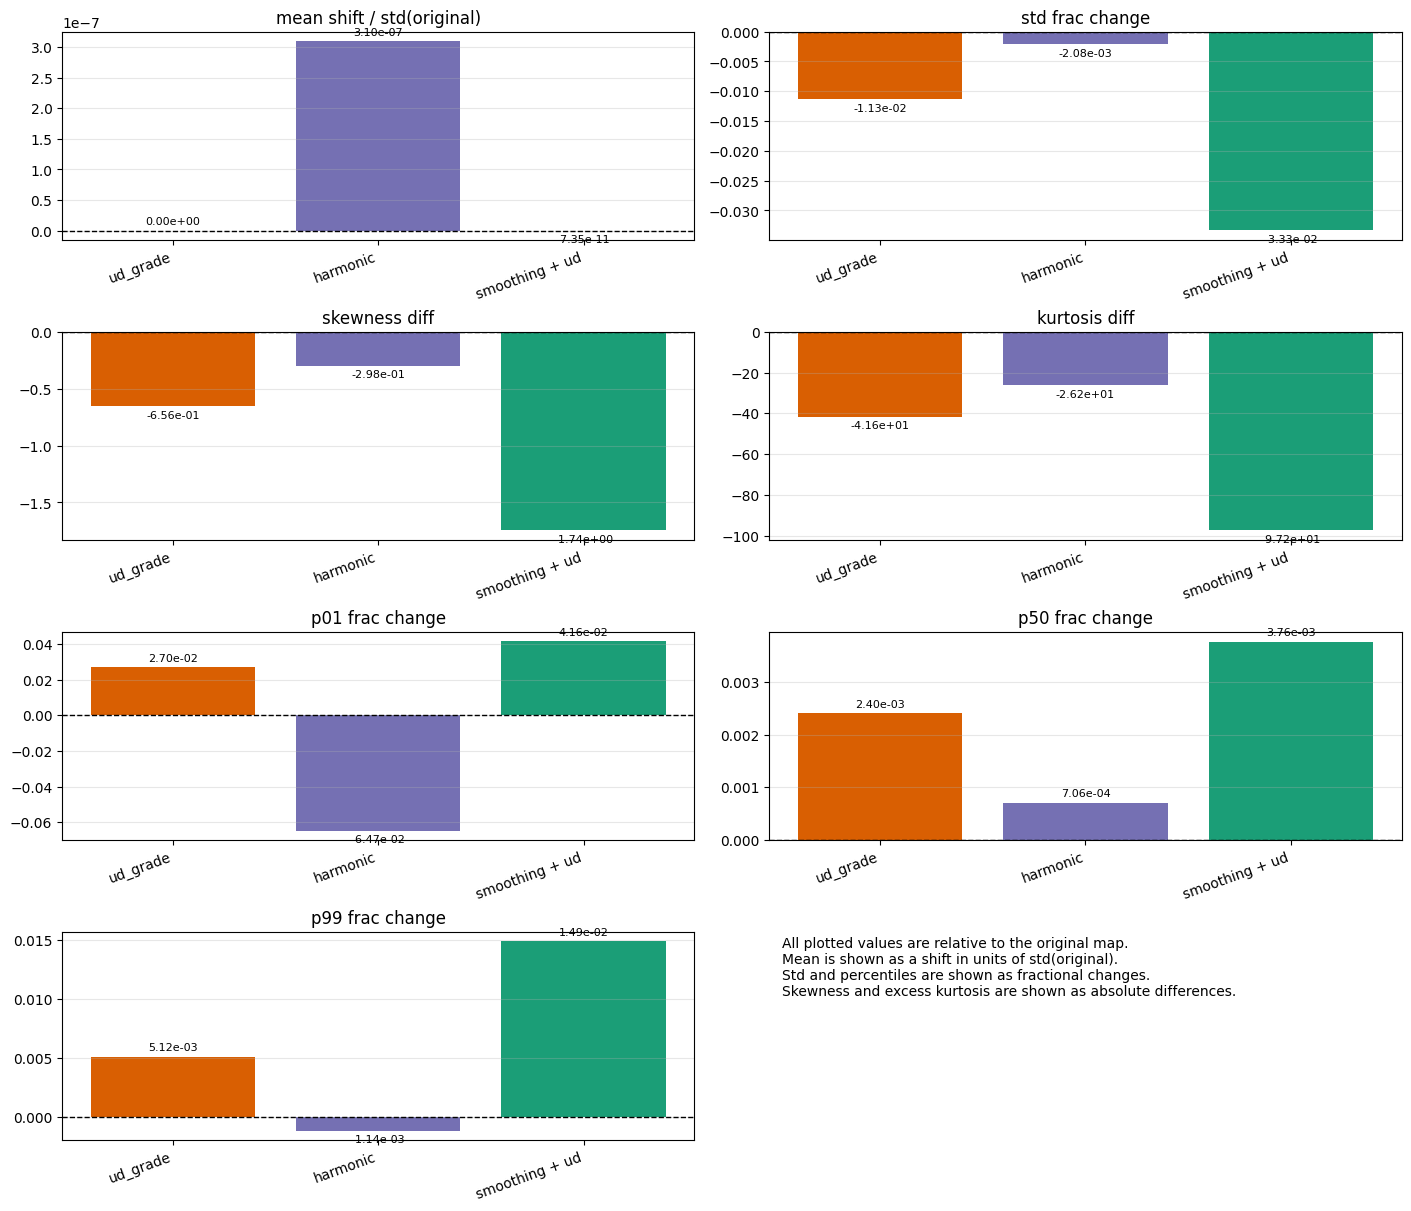

In [13]:
from scipy.stats import skew, kurtosis

def finite_values(m):
    vals = np.asarray(m)
    return vals[np.isfinite(vals)]

def one_point_stats(m):
    vals = finite_values(m)
    return {
        'mean': float(np.mean(vals)),
        'std': float(np.std(vals)),
        'skewness': float(skew(vals, bias=False)),
        'excess_kurtosis': float(kurtosis(vals, fisher=True, bias=False)),
        'p01': float(np.percentile(vals, 1)),
        'p50': float(np.percentile(vals, 50)),
        'p99': float(np.percentile(vals, 99)),
    }

pixel_stats = {
    'original': one_point_stats(m_d10),
    'ud_grade': one_point_stats(d10_ud),
    'harmonic': one_point_stats(d10_harm),
    'smoothing_plus_ud': one_point_stats(d10_smooth_ud),
}

stat_order = ['mean', 'std', 'skewness', 'excess_kurtosis', 'p01', 'p50', 'p99']
method_order = ['original', 'ud_grade', 'harmonic', 'smoothing_plus_ud']
method_labels = {
    'original': 'original',
    'ud_grade': 'ud_grade',
    'harmonic': 'harmonic',
    'smoothing_plus_ud': 'smoothing + ud',
}

print('d10 one-point pixel statistics:')
header = 'method'.ljust(24) + ''.join(name.rjust(18) for name in stat_order)
print(header)
for method in method_order:
    row = method_labels[method].ljust(24)
    row += ''.join(f"{pixel_stats[method][name]:18.6e}" for name in stat_order)
    print(row)

orig = pixel_stats['original']
plot_specs = [
    ('mean', 'mean shift / std(original)', lambda m: (pixel_stats[m]['mean'] - orig['mean']) / orig['std']),
    ('std', 'std frac change', lambda m: pixel_stats[m]['std'] / orig['std'] - 1.0),
    ('skewness', 'skewness diff', lambda m: pixel_stats[m]['skewness'] - orig['skewness']),
    ('excess_kurtosis', 'kurtosis diff', lambda m: pixel_stats[m]['excess_kurtosis'] - orig['excess_kurtosis']),
    ('p01', 'p01 frac change', lambda m: pixel_stats[m]['p01'] / orig['p01'] - 1.0),
    ('p50', 'p50 frac change', lambda m: pixel_stats[m]['p50'] / orig['p50'] - 1.0),
    ('p99', 'p99 frac change', lambda m: pixel_stats[m]['p99'] / orig['p99'] - 1.0),
]

x = np.arange(len(method_order) - 1)
colors = ['#d95f02', '#7570b3', '#1b9e77', '#666666']
fig, axes = plt.subplots(4, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.flat
for ax, (_, title, func) in zip(axes, plot_specs):
    values = np.array([func(m) for m in method_order[1:]], dtype=float)
    bars = ax.bar(x, values, color=colors)
    ax.axhline(0.0, color='black', linestyle='--', linewidth=1)
    ax.set_xticks(x, [method_labels[m] for m in method_order[1:]], rotation=20, ha='right')
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)
    ylim = ax.get_ylim()
    offset = 0.02 * (ylim[1] - ylim[0]) if ylim[1] != ylim[0] else 0.0
    for b, v in zip(bars, values):
        va = 'bottom' if v >= 0 else 'top'
        y = v + offset if v >= 0 else v - offset
        ax.text(b.get_x() + b.get_width() / 2.0, y, f'{v:.2e}', ha='center', va=va, fontsize=8)

axes[len(plot_specs)].axis('off')
axes[len(plot_specs)].text(
    0.02,
    0.98,
    'All plotted values are relative to the original map.\n'
    'Mean is shown as a shift in units of std(original).\n'
    'Std and percentiles are shown as fractional changes.\n'
    'Skewness and excess kurtosis are shown as absolute differences.',
    va='top',
    ha='left',
    fontsize=10,
)
plt.show()

### How to read the pixel-space moments
- `mean shift / std(original)` measures a global offset in units of the original map standard deviation.
- `std frac change` shows whether a method broadens or narrows the pixel distribution.
- `skewness diff` tracks changes in asymmetry of the pixel histogram.
- `kurtosis diff` tracks changes in tail weight relative to the original map.

These are one-point statistics, so they do not test morphology directly.
They are useful here because they can be computed on both the original map and all downgraded maps without treating any downgrade method as the truth reference.

A small mean shift for the harmonic method is expected and is not a sign of a meaningful bias here. `ud_grade` works by pixel-space averaging, which tends to preserve the global mean very directly. `harmonic_ud_grade` goes through spherical-harmonic analysis and synthesis, so tiny differences can appear from floating-point arithmetic and finite `lmax` truncation. In this notebook the mean differences are many orders of magnitude smaller than the map standard deviation, so they should be interpreted as numerically negligible.

## Conclusion
For the real d10 example, the notebook compares downgrade methods using diagnostics tied back to the original map rather than by treating any downgraded map as ground truth.

Across the unmasked spectrum, the masked spectrum, and the pixel-space one-point statistics, `harmonic_ud_grade` gives the best overall compromise among the methods compared here. It preserves more of the original target-bandlimited structure than `smoothing + ud`, while remaining a cleaner approximation to the original map after downgrade than `ud_grade` across the diagnostics included in this notebook.

That does not mean the harmonic downgrade is a truth map for the real-data case. It means that, when all methods are judged against the same original-map-based diagnostics, `harmonic_ud_grade` comes out as the better downgrade choice for this example.